<a href="https://colab.research.google.com/github/urvashi5555/Fake-news-detection-comparing-classical-ML-neural-networks-and-transformers/blob/main/01_SVM_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

print("Fake Dataset Shape:", fake.shape)
print("Real Dataset Shape:", real.shape)

print("\nNumber of fake articles:", len(fake))
print("Number of real articles:", len(real))

Fake Dataset Shape: (23481, 4)
Real Dataset Shape: (21417, 4)

Number of fake articles: 23481
Number of real articles: 21417


In [ ]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

fake["label"] = 0
real["label"] = 1

df = pd.concat([fake, real], ignore_index=True)

df["content"] = df["title"] + " " + df["text"]

df = df[["content", "label"]]

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)

print(df.head())

(44898, 2)
                                             content  label
0  Ben Stein Calls Out 9th Circuit Court: Committ...      0
1  Trump drops Steve Bannon from National Securit...      1
2  Puerto Rico expects U.S. to lift Jones Act shi...      1
3   OOPS: Trump Just Accidentally Confirmed He Le...      0
4  Donald Trump heads for Scotland to reopen a go...      1


In [ ]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)

    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenize
    words = text.split()

    # remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# APPLY CLEANING
df["content"] = df["content"].apply(clean_text)

print("Cleaning completed")

Cleaning completed


In [ ]:
X = df["content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 35918
Test size: 8980


In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

print(X_test_tfidf.shape)

(35918, 5000)
(8980, 5000)


In [ ]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

print("SVM training completed")

SVM training completed


In [ ]:
y_pred = svm_model.predict(X_test_tfidf)

print("Predictions completed")

Predictions completed


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", accuracy)

print("SVM Accuracy (%):", accuracy * 100)

SVM Accuracy: 0.995879732739421
SVM Accuracy (%): 99.5879732739421


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



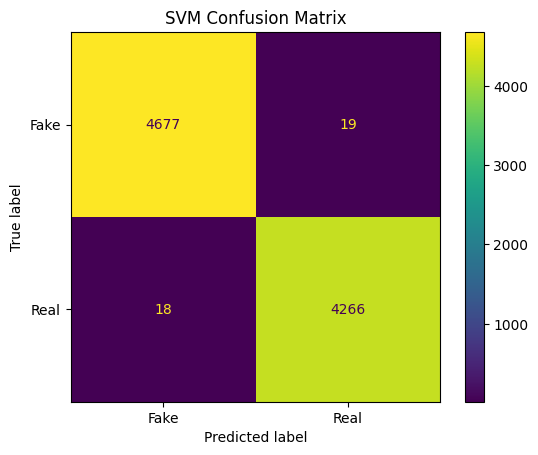

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()

plt.title("SVM Confusion Matrix")

plt.show()

In [ ]:
X_train_dense = X_train_tfidf.toarray()

X_test_dense = X_test_tfidf.toarray()

print(X_train_dense.shape)

print(X_test_dense.shape)

(35918, 5000)
(8980, 5000)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann_model = Sequential()

# INPUT + HIDDEN LAYER 1
ann_model.add(
    Dense(
        256,
        activation='relu',
        input_shape=(5000,)
    )
)

ann_model.add(Dropout(0.3))

# HIDDEN LAYER 2
ann_model.add(
    Dense(
        128,
        activation='relu'
    )
)

ann_model.add(Dropout(0.3))

# OUTPUT LAYER
ann_model.add(
    Dense(
        2,
        activation='softmax'
    )
)

# COMPILE MODEL
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# SHOW MODEL
ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,410 (5.01 MB)

 Trainable params: 1,313,410 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_ann = ann_model.fit(
    X_train_dense,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.9764 - loss: 0.0629 - val_accuracy: 0.9928 - val_loss: 0.0236
Epoch 2/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9972 - loss: 0.0094 - val_accuracy: 0.9939 - val_loss: 0.0207
Epoch 3/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9987 - loss: 0.0042 - val_accuracy: 0.9933 - val_loss: 0.0294
Epoch 4/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9990 - loss: 0.0025 - val_accuracy: 0.9942 - val_loss: 0.0267
Epoch 5/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.9992 - loss: 0.0031 - val_accuracy: 0.9947 - val_loss: 0.0271


In [ ]:
ann_pred = ann_model.predict(X_test_dense)

ann_pred = np.argmax(ann_pred, axis=1)

print("Prediction completed")

281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Prediction completed


In [ ]:
ann_accuracy = accuracy_score(y_test, ann_pred)

print("ANN Test Accuracy:", ann_accuracy)

print("ANN Test Accuracy (%):", ann_accuracy * 100)

ANN Test Accuracy: 0.9919821826280624
ANN Test Accuracy (%): 99.19821826280624


In [ ]:
from tensorflow.keras.layers import LeakyReLU

activations = {
    "relu": "relu",
    "tanh": "tanh",
    "sigmoid": "sigmoid",
    "leaky_relu": LeakyReLU()
}

activation_results = {}

for name, activation in activations.items():

    print(f"\nTraining with {name}")

    model = Sequential()

    model.add(Dense(256, input_shape=(5000,)))

    if name == "leaky_relu":
        model.add(LeakyReLU())
    else:
        model.add(Dense(256, activation=activation, input_shape=(5000,)))

    model.add(Dropout(0.3))

    if name == "leaky_relu":
        model.add(Dense(128))
        model.add(LeakyReLU())
    else:
        model.add(Dense(128, activation=activation))

    model.add(Dropout(0.3))

    model.add(Dense(2, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train_dense,
        y_train,
        epochs=3,
        batch_size=32,
        verbose=0
    )

    pred = model.predict(X_test_dense, verbose=0)

    pred = np.argmax(pred, axis=1)

    acc = accuracy_score(y_test, pred)

    activation_results[name] = acc

# RESULTS
print("\nActivation Function Results")

for k, v in activation_results.items():
    print(f"{k}: {v*100:.2f}%")


Training with relu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with tanh


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with sigmoid


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with leaky_relu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Activation Function Results
relu: 99.03%
tanh: 99.03%
sigmoid: 99.19%
leaky_relu: 99.08%


In [ ]:
from tensorflow.keras.layers import LeakyReLU

activations = ["relu", "tanh", "sigmoid", "leaky_relu"]

activation_results = {}

for act in activations:

    print(f"\nTraining with {act}")

    model = Sequential()

    # FIRST LAYER
    if act == "leaky_relu":

        model.add(Dense(256, input_shape=(5000,)))
        model.add(LeakyReLU())

    else:

        model.add(
            Dense(
                256,
                activation=act,
                input_shape=(5000,)
            )
        )

    model.add(Dropout(0.3))

    # SECOND LAYER
    if act == "leaky_relu":

        model.add(Dense(128))
        model.add(LeakyReLU())

    else:

        model.add(Dense(128, activation=act))

    model.add(Dropout(0.3))

    # OUTPUT
    model.add(Dense(2, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train_dense,
        y_train,
        epochs=3,
        batch_size=32,
        verbose=0
    )

    pred = model.predict(X_test_dense, verbose=0)

    pred = np.argmax(pred, axis=1)

    acc = accuracy_score(y_test, pred)

    activation_results[act] = acc

# RESULTS
print("\n Activation Results")

for k, v in activation_results.items():
    print(f"{k}: {v*100:.2f}%")


Training with relu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with tanh


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with sigmoid


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with leaky_relu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Corrected Activation Results
relu: 99.16%
tanh: 98.85%
sigmoid: 99.20%
leaky_relu: 99.16%


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import (
    Adam,
    RMSprop,
    SGD,
    AdamW
)

tf.keras.backend.clear_session()

optimizers = {
    "RMSProp": RMSprop(learning_rate=0.001),

    "AdamW": AdamW(
        learning_rate=0.001,
        weight_decay=1e-4
    ),

    "SGD_Momentum": SGD(
        learning_rate=0.01,
        momentum=0.9
    ),

    "Adam": Adam(
        learning_rate=0.001
    ),

    "SGD": SGD(
        learning_rate=0.1
    )
}

optimizer_results = {}

for name, opt in optimizers.items():

    print(f"\nTraining with {name}")

    tf.keras.backend.clear_session()

    model = Sequential()

    model.add(
        Dense(
            256,
            activation='relu',
            input_shape=(5000,)
        )
    )

    model.add(Dropout(0.3))

    model.add(Dense(128, activation='relu'))

    model.add(Dropout(0.3))

    model.add(Dense(2, activation='softmax'))

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train_dense,
        y_train,
        epochs=3,
        batch_size=64,
        shuffle=False,
        verbose=0
    )

    pred = model.predict(X_test_dense, verbose=0)

    pred = np.argmax(pred, axis=1)

    acc = accuracy_score(y_test, pred)

    optimizer_results[name] = acc

print("\n Optimizer Results")

for k, v in optimizer_results.items():
    print(f"{k}: {v*100:.2f}%")


Training with RMSProp


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with AdamW


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with SGD_Momentum


...


Training with Adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 Optimizer Results
RMSProp: 99.40%
AdamW: 99.22%
SGD_Momentum: 99.08%
Adam: 99.24%
SGD: 99.13%
